# 📊 App User Behavior Segmentation Using Unsupervised Machine Learning

## Project Objective

This project analyzes app user activity and engagement data and uses **K-Means clustering** to segment users into meaningful behavioral groups without a predefined target variable.

### Business objectives
- Identify highly engaged users for loyalty and premium opportunities
- Detect low-engagement / at-risk users for retention campaigns
- Understand moderate and occasional usage patterns
- Support personalized engagement and product decisions

### Workflow
**Data Loading → Data Understanding → Data Cleaning → EDA → Feature Selection → Feature Engineering → StandardScaler → Elbow Method + Silhouette Score → K-Means → PCA → Cluster Profiling → User-Level Identification → Business Action Mapping**


## 0. Install Project Libraries

In [2]:
import sys
import subprocess

packages = [
    "numpy",
    "pandas",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "joblib",
    "openpyxl"
]

print("Notebook Python:")
print(sys.executable)
print("\nInstalling/checking required packages...")

subprocess.check_call([
    sys.executable, "-m", "pip", "install", *packages
])

print("\nPackage installation/check completed successfully. ✅")


Notebook Python:
d:\app-user-behavior-segmentation\venv\Scripts\python.exe

Installing/checking required packages...

Package installation/check completed successfully. ✅


## 1. Import Libraries

In [3]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import joblib

warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42

# Project paths
PROJECT_ROOT = Path("..")
DATA_PATH = PROJECT_ROOT / "data" / "app_user_behavior_dataset.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
VIZ_DIR = OUTPUT_DIR / "visualizations"
MODEL_DIR = PROJECT_ROOT / "models"

# Create output directories
OUTPUT_DIR.mkdir(exist_ok=True)
VIZ_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

# Plot settings
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("All libraries imported successfully. ✅")
print("Python:", sys.version)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)


All libraries imported successfully. ✅
Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
NumPy: 2.4.6
Pandas: 3.0.5


## 2. Load the Dataset

In [4]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH.resolve()}\n"
        "Make sure app_user_behavior_dataset.csv is inside the data folder."
    )

df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded successfully. ✅")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
display(df.head())


Dataset loaded successfully. ✅
Rows: 50,000
Columns: 25


,user_id,age,gender,country,device_type,app_version,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,notifications_opened_per_week,in_app_search_count,pages_viewed_per_session,crash_events_last_30_days,support_tickets_raised,days_since_last_login,subscription_type,ads_clicked_last_30_days,content_downloads,social_shares,rating_given,churn_risk_score,engagement_score,account_age_days,marketing_source
0,100000,56,Female,India,iOS,2.1,5,3.41,52.71,13,5,8,8,1,0,20,Basic,9,5,2,NaN,0.31,55.79,1152,Referral
1,100001,46,Male,UK,iOS,1.0,8,24.44,42.03,7,7,3,7,0,0,7,Free,8,3,3,3.0,0.87,82.39,1059,Email Campaign
2,100002,32,Female,UK,iOS,1.2,12,5.34,76.69,7,5,2,21,1,0,33,Free,11,6,1,2.0,0.63,42.49,678,Google Ads
3,100003,25,Male,India,Android,2.0,5,3.98,65.38,16,8,4,13,0,0,17,Basic,6,3,1,3.0,0.43,62.81,92,Organic
4,100004,38,Male,Australia,Android,1.0,10,12.85,57.06,13,7,3,15,0,0,21,Basic,4,4,2,5.0,0.43,38.21,772,Email Campaign


## 3. Basic Dataset Understanding

In [5]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")


Dataset Shape:
(50000, 25)

Column Names:
1. user_id
2. age
3. gender
4. country
5. device_type
6. app_version
7. sessions_per_week
8. avg_session_duration_min
9. daily_active_minutes
10. feature_clicks_per_session
11. notifications_opened_per_week
12. in_app_search_count
13. pages_viewed_per_session
14. crash_events_last_30_days
15. support_tickets_raised
16. days_since_last_login
17. subscription_type
18. ads_clicked_last_30_days
19. content_downloads
20. social_shares
21. rating_given
22. churn_risk_score
23. engagement_score
24. account_age_days
25. marketing_source


In [6]:
print("Data Types:")
display(df.dtypes.to_frame("data_type"))


Data Types:


,data_type
user_id,int64
age,int64
gender,str
country,str
device_type,str
app_version,float64
sessions_per_week,int64
avg_session_duration_min,float64
daily_active_minutes,float64
feature_clicks_per_session,int64


In [7]:
print("Dataset Information:")
df.info()


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   user_id                        50000 non-null  int64  
 1   age                            50000 non-null  int64  
 2   gender                         50000 non-null  str    
 3   country                        50000 non-null  str    
 4   device_type                    50000 non-null  str    
 5   app_version                    50000 non-null  float64
 6   sessions_per_week              50000 non-null  int64  
 7   avg_session_duration_min       50000 non-null  float64
 8   daily_active_minutes           50000 non-null  float64
 9   feature_clicks_per_session     50000 non-null  int64  
 10  notifications_opened_per_week  50000 non-null  int64  
 11  in_app_search_count            50000 non-null  int64  
 12  pages_viewed_per_session       50000

In [8]:
print("Descriptive Statistics:")
display(df.describe(include="all").T)


Descriptive Statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,50000.0,NaN,NaN,NaN,124999.5,14433.901067,100000.0,112499.75,124999.5,137499.25,149999.0
age,50000.0,NaN,NaN,NaN,38.51304,12.094948,18.0,28.0,39.0,49.0,59.0
gender,50000,3,Female,23994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,50000,7,India,22550,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device_type,50000,3,Android,27315,NaN,NaN,NaN,NaN,NaN,NaN,NaN
app_version,50000.0,NaN,NaN,NaN,1.476126,0.470158,1.0,1.1,1.2,2.0,2.1
sessions_per_week,50000.0,NaN,NaN,NaN,7.99968,2.829438,0.0,6.0,8.0,10.0,26.0
avg_session_duration_min,50000.0,NaN,NaN,NaN,13.149842,8.946944,0.06,6.57,11.24,17.57,91.4
daily_active_minutes,50000.0,NaN,NaN,NaN,45.164537,19.505118,5.0,31.65,45.21,58.44,129.13
feature_clicks_per_session,50000.0,NaN,NaN,NaN,12.01392,3.480289,1.0,10.0,12.0,14.0,28.0


In [9]:
print("Duplicate Rows:", df.duplicated().sum())

missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": (df.isnull().mean() * 100).round(2)
}).sort_values("missing_count", ascending=False)

print("\nMissing Value Summary:")
display(missing_summary[missing_summary["missing_count"] > 0])


Duplicate Rows: 0

Missing Value Summary:


,missing_count,missing_percentage
rating_given,5022,10.04


## 4. Data Cleaning

The clustering model should use behavioral and engagement information rather than identifiers or demographic labels.

We will:
- Remove exact duplicate rows if present
- Check numerical columns for invalid negative values
- Keep `user_id` for final user-level identification, but never use it as a clustering feature
- Exclude `rating_given` from clustering because it contains missing values and is not required for the behavioral segmentation objective


In [10]:
# Remove exact duplicate rows
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
removed_duplicates = before - len(df)

print(f"Duplicate rows removed: {removed_duplicates}")
print(f"Dataset shape after cleaning duplicates: {df.shape}")


Duplicate rows removed: 0
Dataset shape after cleaning duplicates: (50000, 25)


In [11]:
# Identify numeric and categorical columns
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)


Numeric columns:
['user_id', 'age', 'app_version', 'sessions_per_week', 'avg_session_duration_min', 'daily_active_minutes', 'feature_clicks_per_session', 'notifications_opened_per_week', 'in_app_search_count', 'pages_viewed_per_session', 'crash_events_last_30_days', 'support_tickets_raised', 'days_since_last_login', 'ads_clicked_last_30_days', 'content_downloads', 'social_shares', 'rating_given', 'churn_risk_score', 'engagement_score', 'account_age_days']

Categorical columns:
['gender', 'country', 'device_type', 'subscription_type', 'marketing_source']


In [12]:
# Check negative values in numeric columns
negative_counts = (df[numeric_columns] < 0).sum().sort_values(ascending=False)

print("Negative-value check:")
display(
    negative_counts[negative_counts > 0].to_frame("negative_count")
)


Negative-value check:


,negative_count


In [13]:
# Inspect the rating column, if present
if "rating_given" in df.columns:
    print("rating_given missing values:", df["rating_given"].isna().sum())
    display(df["rating_given"].value_counts(dropna=False).sort_index())


rating_given missing values: 5022


rating_given
1.0     2518
2.0     3885
3.0    11199
4.0    17465
5.0     9911
NaN     5022
Name: count, dtype: int64

## 5. Exploratory Data Analysis (EDA)

EDA is used to understand user behavior before clustering.

We will examine:
- Behavioral feature distributions
- Categorical distributions
- Correlations between behavioral metrics
- Engagement and churn-related patterns


In [14]:
# Behavioral columns available in the dataset
behavior_features = [
    "sessions_per_week",
    "avg_session_duration_min",
    "daily_active_minutes",
    "feature_clicks_per_session",
    "notifications_opened_per_week",
    "in_app_search_count",
    "pages_viewed_per_session",
    "crash_events_last_30_days",
    "support_tickets_raised",
    "days_since_last_login",
    "ads_clicked_last_30_days",
    "content_downloads",
    "social_shares",
    "churn_risk_score",
    "engagement_score"
]

missing_behavior_columns = [
    col for col in behavior_features if col not in df.columns
]

if missing_behavior_columns:
    raise ValueError(
        f"Expected behavioral columns not found: {missing_behavior_columns}"
    )

print(f"Behavioral features available: {len(behavior_features)}")
display(df[behavior_features].describe().T)


Behavioral features available: 15


,count,mean,std,min,25%,50%,75%,max
sessions_per_week,50000.0,7.999680,2.829438,0.00,6.00,8.000,10.00,26.00
avg_session_duration_min,50000.0,13.149842,8.946944,0.06,6.57,11.240,17.57,91.40
daily_active_minutes,50000.0,45.164537,19.505118,5.00,31.65,45.210,58.44,129.13
feature_clicks_per_session,50000.0,12.013920,3.480289,1.00,10.00,12.000,14.00,28.00
notifications_opened_per_week,50000.0,4.996620,2.235180,0.00,3.00,5.000,6.00,16.00
in_app_search_count,50000.0,3.999060,1.997763,0.00,3.00,4.000,5.00,19.00
pages_viewed_per_session,50000.0,13.470760,6.343635,3.00,8.00,13.000,19.00,24.00
crash_events_last_30_days,50000.0,0.397520,0.633992,0.00,0.00,0.000,1.00,5.00
support_tickets_raised,50000.0,0.196660,0.444420,0.00,0.00,0.000,0.00,4.00
days_since_last_login,50000.0,22.038240,12.985237,0.00,11.00,22.000,33.00,44.00


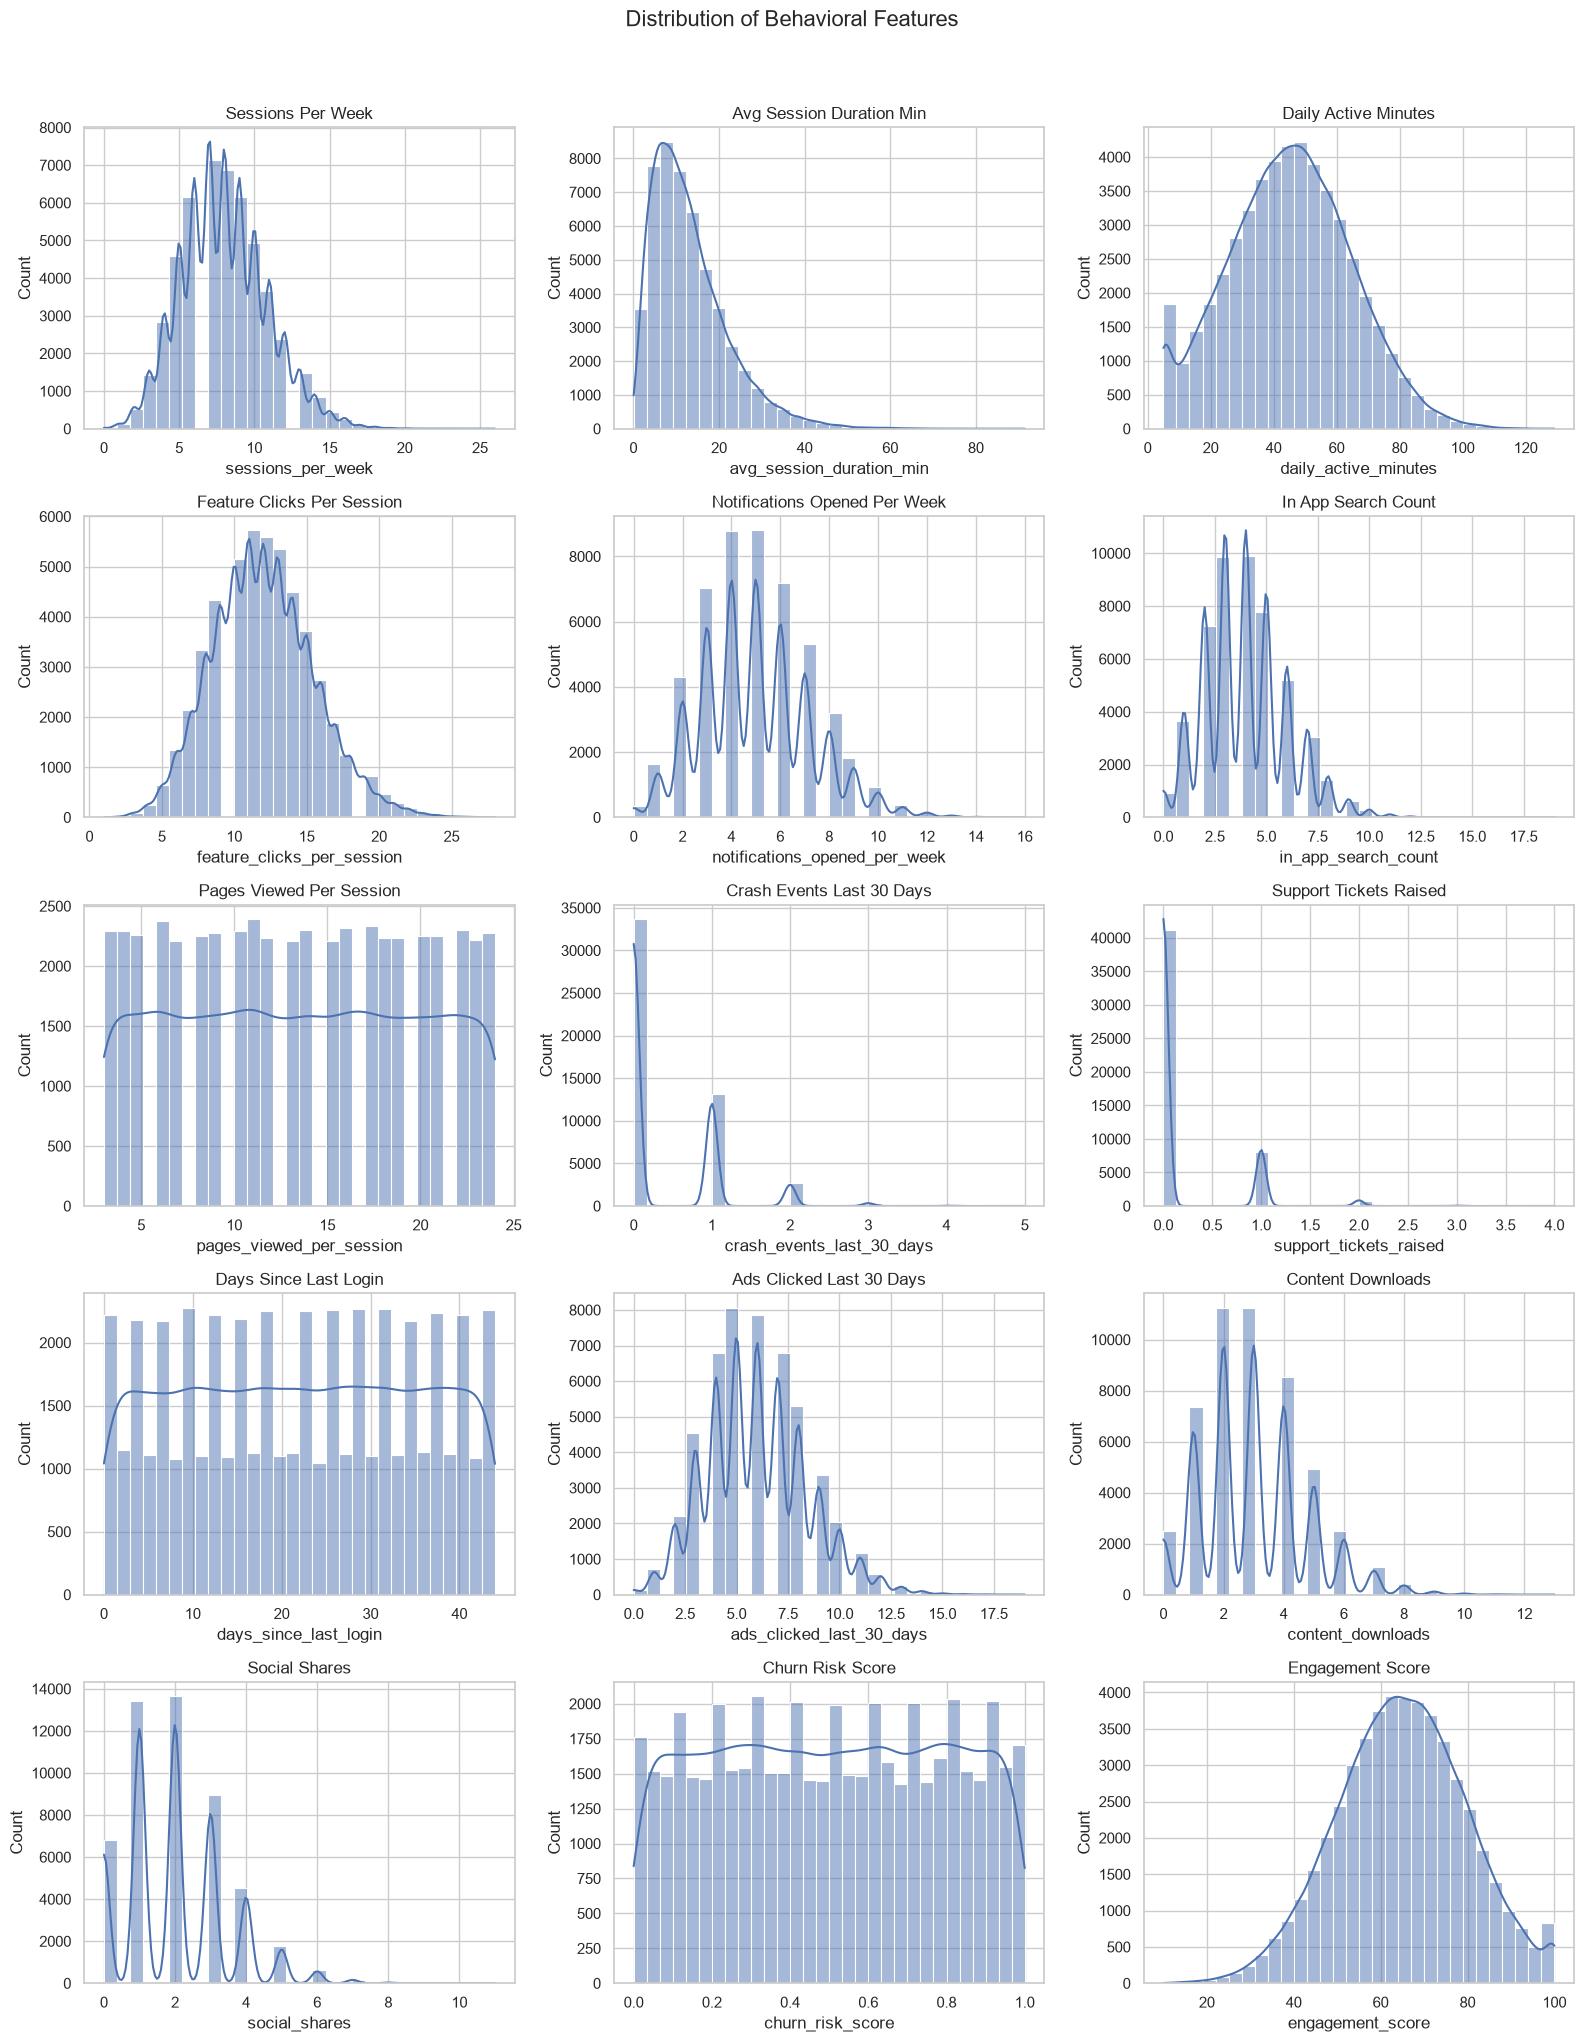

In [15]:
# Distribution plots
n_cols = 3
n_rows = int(np.ceil(len(behavior_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, behavior_features):
    sns.histplot(df[col], bins=30, kde=True, ax=ax)
    ax.set_title(col.replace("_", " ").title())

for ax in axes[len(behavior_features):]:
    ax.remove()

plt.suptitle("Distribution of Behavioral Features", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(VIZ_DIR / "distributions.png", dpi=150, bbox_inches="tight")
plt.show()


In [16]:
# Categorical distributions
categorical_eda_cols = [
    col for col in [
        "gender",
        "country",
        "device_type",
        "subscription_type",
        "marketing_source"
    ]
    if col in df.columns
]

for col in categorical_eda_cols:
    print(f"\n{col}:")
    display(df[col].value_counts(dropna=False).head(15))



gender:


gender
Female    23994
Male      23936
Other      2070
Name: count, dtype: int64


country:


country
India        22550
USA           9115
UK            5043
Canada        3853
Australia     3498
Germany       3425
Singapore     2516
Name: count, dtype: int64


device_type:


device_type
Android    27315
iOS        17662
Web         5023
Name: count, dtype: int64


subscription_type:


subscription_type
Free       30088
Basic      12495
Premium     7417
Name: count, dtype: int64


marketing_source:


marketing_source
Organic           17539
Google Ads        12468
Referral           7539
Facebook Ads       7463
Email Campaign     4991
Name: count, dtype: int64

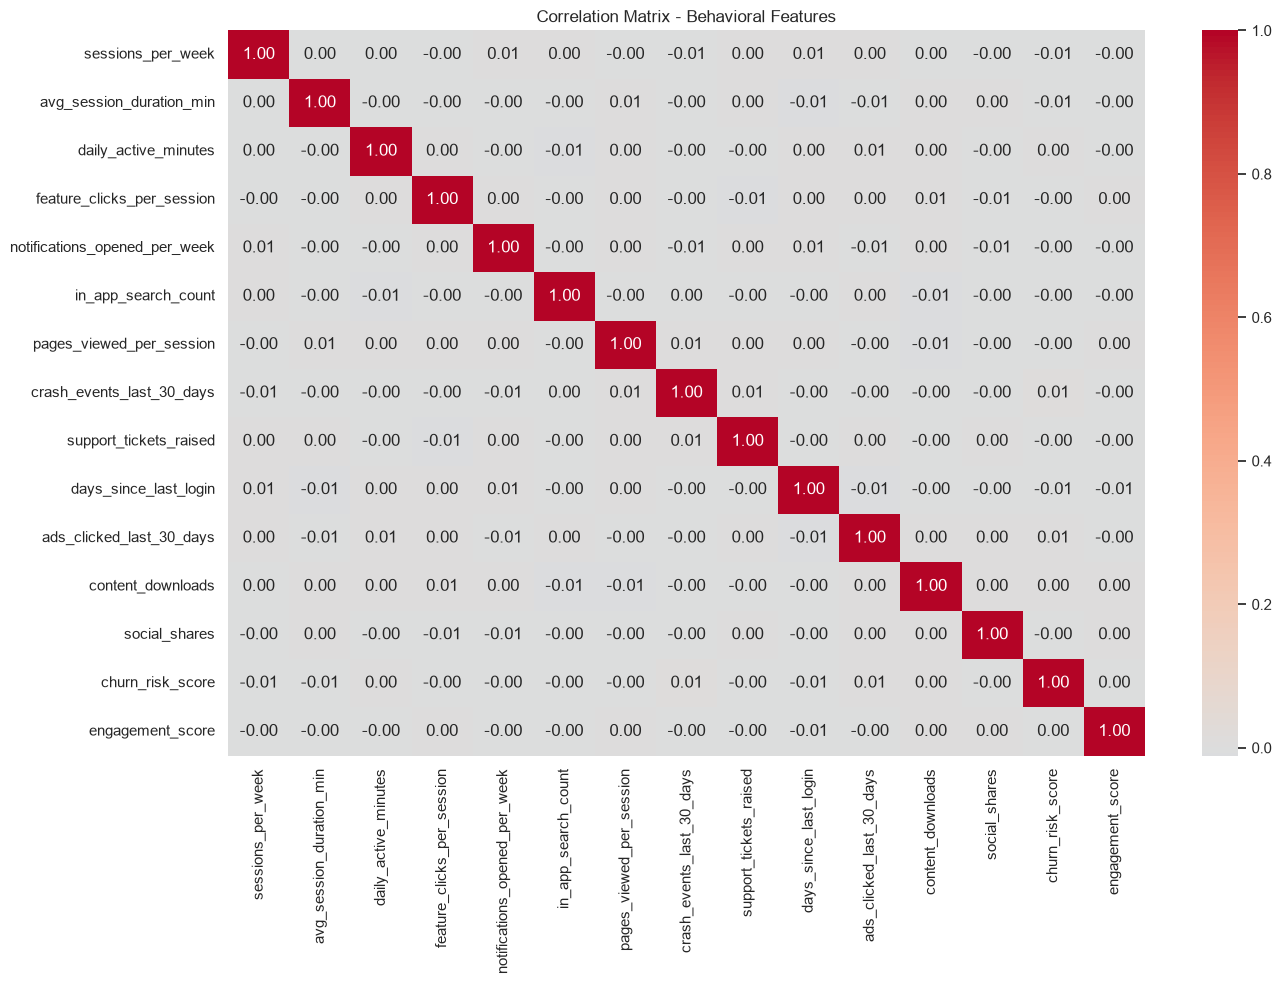

In [17]:
# Correlation matrix
correlation_matrix = df[behavior_features].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix - Behavioral Features")
plt.tight_layout()
plt.savefig(VIZ_DIR / "correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


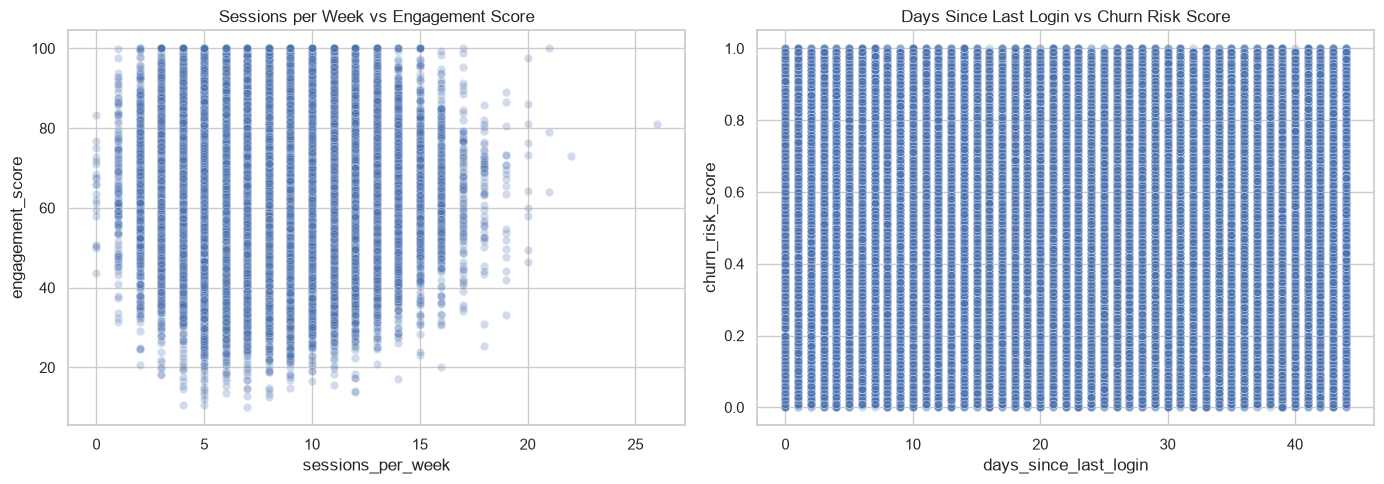

In [18]:
# Two useful behavioral relationships
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=df,
    x="sessions_per_week",
    y="engagement_score",
    alpha=0.25,
    ax=axes[0]
)
axes[0].set_title("Sessions per Week vs Engagement Score")

sns.scatterplot(
    data=df,
    x="days_since_last_login",
    y="churn_risk_score",
    alpha=0.25,
    ax=axes[1]
)
axes[1].set_title("Days Since Last Login vs Churn Risk Score")

plt.tight_layout()
plt.show()


## 6. Feature Selection

The clustering model focuses on numerical variables that represent:
- Usage frequency
- Session duration
- Daily activity
- Feature interaction
- Search and page activity
- Content/social interaction
- Inactivity
- Engagement
- Churn risk

### Excluded
- `user_id`: identifier only
- Demographic fields such as age/gender/country
- Device/app-version fields
- Subscription/marketing source fields
- `rating_given`: not required for behavioral clustering and contains missing values
- `account_age_days`: tenure rather than direct engagement behavior

This keeps the model focused on **user behavior and engagement**.


In [19]:
X = df[behavior_features].copy()

print("Clustering feature matrix shape:", X.shape)
display(X.head())


Clustering feature matrix shape: (50000, 15)


,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,notifications_opened_per_week,in_app_search_count,pages_viewed_per_session,crash_events_last_30_days,support_tickets_raised,days_since_last_login,ads_clicked_last_30_days,content_downloads,social_shares,churn_risk_score,engagement_score
0,5,3.41,52.71,13,5,8,8,1,0,20,9,5,2,0.31,55.79
1,8,24.44,42.03,7,7,3,7,0,0,7,8,3,3,0.87,82.39
2,12,5.34,76.69,7,5,2,21,1,0,33,11,6,1,0.63,42.49
3,5,3.98,65.38,16,8,4,13,0,0,17,6,3,1,0.43,62.81
4,10,12.85,57.06,13,7,3,15,0,0,21,4,4,2,0.43,38.21


## 7. Feature Quality Check

Before scaling, check for missing values and highly correlated features.

We will not automatically remove correlated variables because several engagement metrics can legitimately describe different aspects of user behavior. PCA will also help summarize correlated dimensions.


In [20]:
feature_missing = X.isnull().sum().sort_values(ascending=False)

print("Missing values in clustering features:")
display(feature_missing[feature_missing > 0])


Missing values in clustering features:


Series([], dtype: int64)

In [21]:
# Median imputation only if clustering features contain missing values
if X.isnull().sum().sum() > 0:
    print("Missing values found. Applying median imputation.")
    X = X.fillna(X.median(numeric_only=True))
else:
    print("No missing values found in clustering features. ✅")


No missing values found in clustering features. ✅


In [22]:
# Highly correlated feature pairs
corr_abs = X.corr().abs()
high_corr_pairs = []

for i in range(len(corr_abs.columns)):
    for j in range(i + 1, len(corr_abs.columns)):
        value = corr_abs.iloc[i, j]
        if value >= 0.80:
            high_corr_pairs.append({
                "feature_1": corr_abs.index[i],
                "feature_2": corr_abs.columns[j],
                "absolute_correlation": round(value, 3)
            })

high_corr_df = pd.DataFrame(high_corr_pairs)

if high_corr_df.empty:
    print("No feature pairs with absolute correlation >= 0.80.")
else:
    display(high_corr_df.sort_values("absolute_correlation", ascending=False))


No feature pairs with absolute correlation >= 0.80.


## 8. Feature Scaling Using StandardScaler

K-Means uses distance calculations. Therefore, features with larger numerical ranges could dominate the clustering process.

`StandardScaler` transforms the selected variables to a comparable scale.


In [23]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=behavior_features
)

print("Scaled feature matrix shape:", X_scaled_df.shape)
display(X_scaled_df.head())


Scaled feature matrix shape: (50000, 15)


,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,notifications_opened_per_week,in_app_search_count,pages_viewed_per_session,crash_events_last_30_days,support_tickets_raised,days_since_last_login,ads_clicked_last_30_days,content_downloads,social_shares,churn_risk_score,engagement_score
0,-1.060179,-1.088633,0.386849,0.283336,0.001512,2.002730,-0.862410,0.950305,-0.442514,-0.156968,1.224561,1.153562,-0.001019,-0.661298,-0.616659
1,0.000113,1.261914,-0.160705,-1.440677,0.896304,-0.500094,-1.020050,-0.627017,-0.442514,-1.158114,0.816944,-0.001305,0.706485,1.279270,1.175953
2,1.413835,-0.872915,1.616282,-1.440677,0.001512,-1.000659,1.186909,0.950305,-0.442514,0.844179,2.039793,1.730996,-0.708522,0.447598,-1.512965
3,-1.060179,-1.024924,1.036429,1.145342,1.343700,0.000471,-0.074211,-0.627017,-0.442514,-0.388001,0.001712,-0.001305,-0.708522,-0.245462,-0.143571
4,0.706974,-0.033514,0.609870,0.283336,0.896304,-0.500094,0.241069,-0.627017,-0.442514,-0.079956,-0.813520,0.576129,-0.001019,-0.245462,-1.801401


In [24]:
print("Scaled feature means (approximately 0):")
display(X_scaled_df.mean().round(4).to_frame("mean"))

print("\nScaled feature standard deviations (approximately 1):")
display(X_scaled_df.std().round(4).to_frame("std"))


Scaled feature means (approximately 0):


,mean
sessions_per_week,0.0
avg_session_duration_min,-0.0
daily_active_minutes,-0.0
feature_clicks_per_session,-0.0
notifications_opened_per_week,-0.0
in_app_search_count,-0.0
pages_viewed_per_session,-0.0
crash_events_last_30_days,0.0
support_tickets_raised,-0.0
days_since_last_login,0.0



Scaled feature standard deviations (approximately 1):


,std
sessions_per_week,1.0
avg_session_duration_min,1.0
daily_active_minutes,1.0
feature_clicks_per_session,1.0
notifications_opened_per_week,1.0
in_app_search_count,1.0
pages_viewed_per_session,1.0
crash_events_last_30_days,1.0
support_tickets_raised,1.0
days_since_last_login,1.0


## 9. Elbow Method

The Elbow Method calculates K-Means inertia for different values of K.

We will inspect K values from 2 to 10 and look for the point where additional clusters provide diminishing improvement.


In [25]:
k_values = range(2, 11)
inertias = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )
    model.fit(X_scaled)
    inertias.append(model.inertia_)

elbow_results = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias
})

display(elbow_results)


,k,inertia
0,2,712396.612208
1,3,673858.712303
2,4,649657.159511
3,5,630904.269135
4,6,616463.706948
5,7,605007.333945
6,8,592165.241047
7,9,581282.637581
8,10,572072.491306


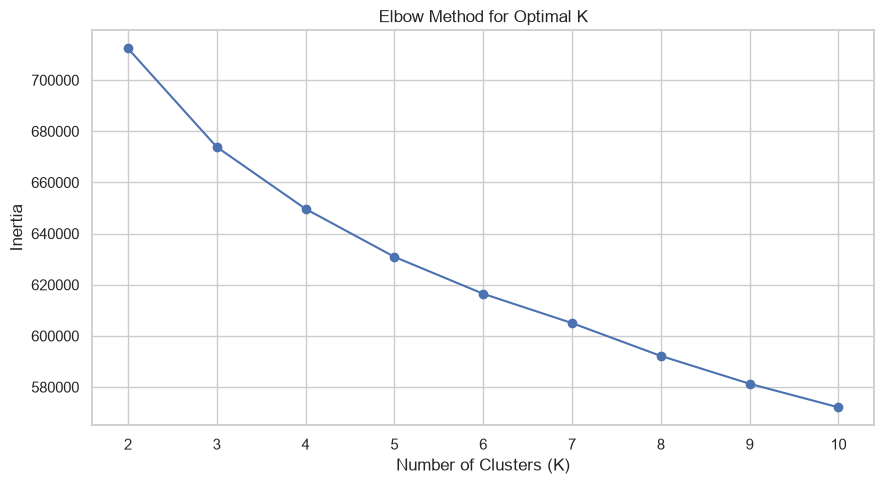

In [26]:
plt.figure(figsize=(9, 5))
plt.plot(elbow_results["k"], elbow_results["inertia"], marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.xticks(list(k_values))
plt.tight_layout()
plt.savefig(VIZ_DIR / "elbow_curve.png", dpi=150, bbox_inches="tight")
plt.show()


## 10. Silhouette Score

The silhouette score provides an additional measure of how well users fit within their assigned cluster compared with other clusters.

Higher values generally indicate better-defined clusters.


In [27]:
silhouette_results = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)

    silhouette_results.append({
        "k": k,
        "silhouette_score": score
    })

silhouette_df = pd.DataFrame(silhouette_results)

display(silhouette_df)


,k,silhouette_score
0,2,0.051587
1,3,0.056808
2,4,0.052776
3,5,0.052193
4,6,0.048941
5,7,0.048024
6,8,0.049322
7,9,0.047435
8,10,0.046202


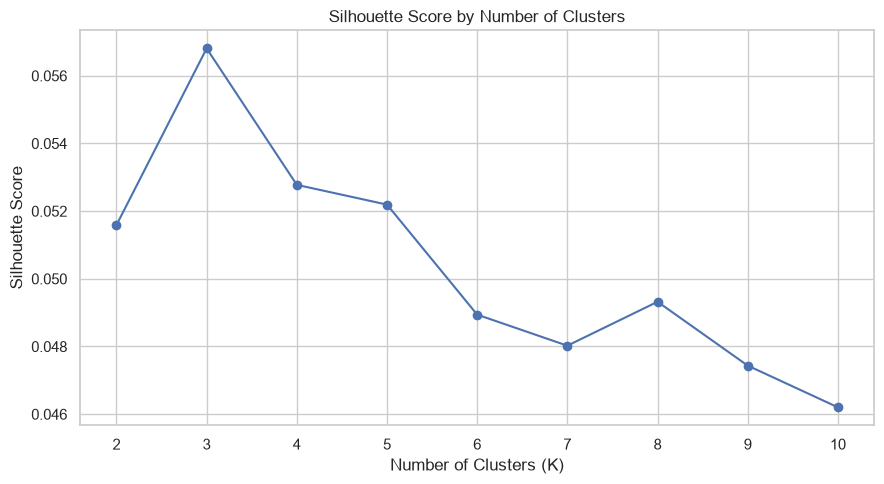

Highest silhouette score occurs at K = 3


In [28]:
plt.figure(figsize=(9, 5))
plt.plot(
    silhouette_df["k"],
    silhouette_df["silhouette_score"],
    marker="o"
)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")
plt.xticks(list(k_values))
plt.tight_layout()
plt.savefig(VIZ_DIR / "silhouette_score.png", dpi=150, bbox_inches="tight")
plt.show()

best_silhouette_k = int(
    silhouette_df.loc[
        silhouette_df["silhouette_score"].idxmax(), "k"
    ]
)

print(f"Highest silhouette score occurs at K = {best_silhouette_k}")


## 11. Train the Final K-Means Model

The project requirement is to identify **four behavioral user groups**.

Therefore, we use **K = 4** for the final business segmentation and validate the result using the Elbow Method and Silhouette Score.

> Note: K-Means cluster numbers are arbitrary. Cluster 0 does not inherently mean "High Engagement." We determine the business meaning from the cluster profiles.


In [29]:
OPTIMAL_K = 4

kmeans = KMeans(
    n_clusters=OPTIMAL_K,
    random_state=RANDOM_STATE,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

df["cluster"] = cluster_labels

print("K-Means model trained successfully. ✅")
print("Number of clusters:", OPTIMAL_K)


K-Means model trained successfully. ✅
Number of clusters: 4


## 12. Evaluate the Final Clustering Model

In [30]:
final_silhouette = silhouette_score(X_scaled, cluster_labels)

print(f"Final K: {OPTIMAL_K}")
print(f"Inertia: {kmeans.inertia_:.2f}")
print(f"Silhouette Score: {final_silhouette:.4f}")

if final_silhouette >= 0.50:
    interpretation = "Strong cluster separation"
elif final_silhouette >= 0.25:
    interpretation = "Reasonable/moderate cluster separation"
else:
    interpretation = "Weak cluster separation; clusters overlap considerably"

print("Interpretation:", interpretation)


Final K: 4
Inertia: 649657.16
Silhouette Score: 0.0528
Interpretation: Weak cluster separation; clusters overlap considerably


In [31]:
cluster_sizes = (
    df["cluster"]
    .value_counts()
    .sort_index()
    .rename("user_count")
    .to_frame()
)

cluster_sizes["percentage"] = (
    cluster_sizes["user_count"] / len(df) * 100
).round(2)

display(cluster_sizes)


,user_count,percentage
cluster,,
0,11599,23.20
1,14660,29.32
2,8392,16.78
3,15349,30.70


## 13. PCA Dimensionality Reduction

PCA reduces the scaled behavioral feature space to two principal components for visualization.

The PCA plot helps us visually inspect whether the discovered groups are separated in the reduced feature space.


In [32]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["cluster"] = cluster_labels

pc1_variance = pca.explained_variance_ratio_[0]
pc2_variance = pca.explained_variance_ratio_[1]
total_variance = pca.explained_variance_ratio_.sum()

print(f"PC1 explained variance: {pc1_variance:.2%}")
print(f"PC2 explained variance: {pc2_variance:.2%}")
print(f"Combined explained variance: {total_variance:.2%}")


PC1 explained variance: 6.86%
PC2 explained variance: 6.83%
Combined explained variance: 13.68%


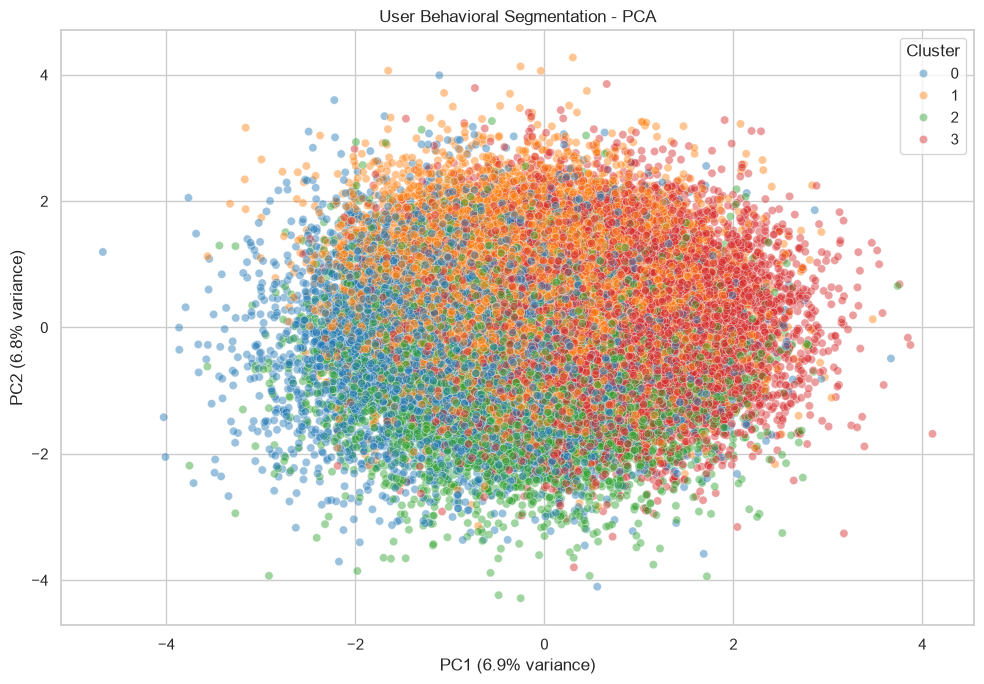

In [33]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",
    alpha=0.45,
    s=35
)

plt.title("User Behavioral Segmentation - PCA")
plt.xlabel(f"PC1 ({pc1_variance:.1%} variance)")
plt.ylabel(f"PC2 ({pc2_variance:.1%} variance)")
plt.legend(title="Cluster")
plt.tight_layout()

plt.savefig(VIZ_DIR / "pca_clusters.png", dpi=150, bbox_inches="tight")
plt.show()


## 14. Cluster Profiling

Now we analyze the average behavior of users in each cluster.

This is the most important step for converting technical cluster IDs into meaningful business segments.


In [34]:
cluster_profile = (
    df.groupby("cluster")[behavior_features]
    .mean()
    .round(2)
)

display(cluster_profile)


,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,notifications_opened_per_week,in_app_search_count,pages_viewed_per_session,crash_events_last_30_days,support_tickets_raised,days_since_last_login,ads_clicked_last_30_days,content_downloads,social_shares,churn_risk_score,engagement_score
cluster,,,,,,,,,,,,,,,
0,7.94,13.08,45.21,12.05,4.97,3.99,13.46,1.30,0.04,22.02,6.02,3.01,1.99,0.58,65.04
1,7.97,13.00,45.49,12.04,5.03,3.98,13.42,0.00,0.00,21.76,6.01,3.01,1.98,0.74,65.08
2,8.02,13.21,45.11,11.96,5.01,4.00,13.46,0.30,1.11,22.02,6.01,2.99,2.01,0.50,64.84
3,8.06,13.32,44.85,11.99,4.98,4.02,13.53,0.15,0.00,22.33,5.95,2.99,2.02,0.22,64.79


In [35]:
# Compare cluster values using z-score-like standardized profile values
profile_scaled = pd.DataFrame(
    scaler.transform(cluster_profile),
    columns=behavior_features,
    index=cluster_profile.index
)

display(profile_scaled.round(2))


,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,notifications_opened_per_week,in_app_search_count,pages_viewed_per_session,crash_events_last_30_days,support_tickets_raised,days_since_last_login,ads_clicked_last_30_days,content_downloads,social_shares,churn_risk_score,engagement_score
cluster,,,,,,,,,,,,,,,
0,-0.02,-0.01,0.00,0.01,-0.01,-0.00,-0.00,1.42,-0.35,-0.00,0.01,0.00,-0.01,0.27,0.01
1,-0.01,-0.02,0.02,0.01,0.01,-0.01,-0.01,-0.63,-0.44,-0.02,0.01,0.00,-0.02,0.83,0.01
2,0.01,0.01,-0.00,-0.02,0.01,0.00,-0.00,-0.15,2.06,-0.00,0.01,-0.01,0.01,-0.00,-0.01
3,0.02,0.02,-0.02,-0.01,-0.01,0.01,0.01,-0.39,-0.44,0.02,-0.02,-0.01,0.01,-0.97,-0.01


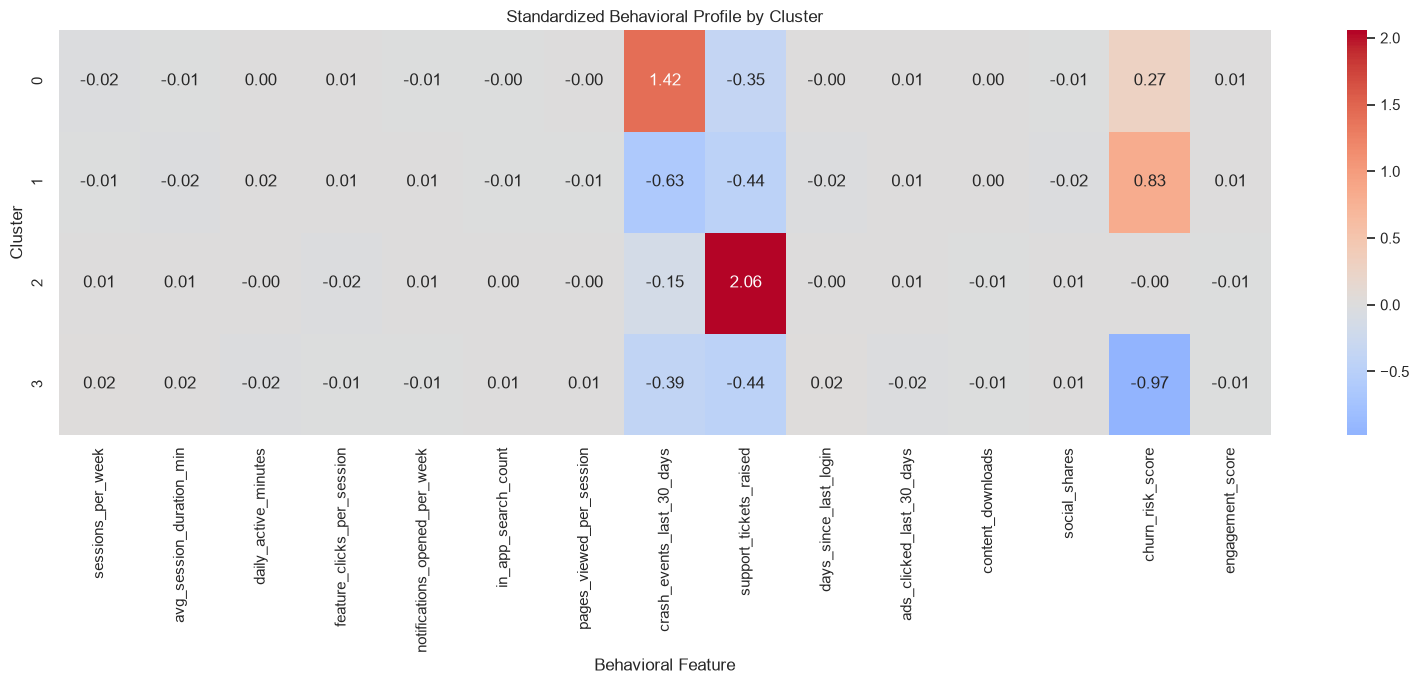

In [36]:
plt.figure(figsize=(16, 7))

sns.heatmap(
    profile_scaled,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Standardized Behavioral Profile by Cluster")
plt.xlabel("Behavioral Feature")
plt.ylabel("Cluster")
plt.tight_layout()

plt.savefig(VIZ_DIR / "cluster_profile_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


## 15. Assign Business-Friendly Segment Names

Because K-Means assigns arbitrary cluster numbers, we determine the segment names from the observed behavioral profiles.

The naming logic considers:
- Overall engagement/activity
- Usage frequency
- Session behavior
- Inactivity
- Churn risk

The labels are assigned after examining the actual cluster characteristics.


In [37]:
# Build interpretable composite indicators from the cluster means.
# These are used only for naming clusters, not for training K-Means.

positive_behavior_cols = [
    "sessions_per_week",
    "avg_session_duration_min",
    "daily_active_minutes",
    "feature_clicks_per_session",
    "notifications_opened_per_week",
    "in_app_search_count",
    "pages_viewed_per_session",
    "content_downloads",
    "social_shares",
    "engagement_score"
]

positive_profile = profile_scaled[positive_behavior_cols].mean(axis=1)

risk_profile = (
    profile_scaled["days_since_last_login"]
    + profile_scaled["churn_risk_score"]
) / 2

cluster_behavior_scores = pd.DataFrame({
    "engagement_activity_score": positive_profile,
    "risk_score": risk_profile
})

display(cluster_behavior_scores.sort_values(
    "engagement_activity_score",
    ascending=False
))


,engagement_activity_score,risk_score
cluster,,
3,0.002564,-0.475353
1,-0.000696,0.403676
2,-0.000741,-0.002148
0,-0.003126,0.136464


In [38]:
# Use the behavioral scores to identify the four business segments.
# Highest activity = High Engagement
# Lowest activity with relatively high risk = Low Engagement / At-Risk
# Remaining two are separated by activity level.

activity_order = cluster_behavior_scores[
    "engagement_activity_score"
].sort_values(ascending=False).index.tolist()

high_cluster = activity_order[0]
low_cluster = activity_order[-1]

middle_clusters = [
    cluster for cluster in activity_order
    if cluster not in [high_cluster, low_cluster]
]

# Higher-activity middle cluster = Moderate
# Lower-activity middle cluster = Occasional
moderate_cluster = middle_clusters[0]
occasional_cluster = middle_clusters[1]

segment_mapping = {
    high_cluster: "High Engagement Users",
    moderate_cluster: "Moderate Engagement Users",
    low_cluster: "Low Engagement / At-Risk Users",
    occasional_cluster: "Occasional Users"
}

df["segment"] = df["cluster"].map(segment_mapping)

print("Final cluster-to-segment mapping:")
for cluster_id in sorted(segment_mapping):
    print(f"Cluster {cluster_id} → {segment_mapping[cluster_id]}")


Final cluster-to-segment mapping:
Cluster 0 → Low Engagement / At-Risk Users
Cluster 1 → Moderate Engagement Users
Cluster 2 → Occasional Users
Cluster 3 → High Engagement Users


## 16. Final Segment Profiles

In [39]:
segment_profile = (
    df.groupby("segment")[behavior_features]
    .mean()
    .round(2)
)

display(segment_profile)


,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,notifications_opened_per_week,in_app_search_count,pages_viewed_per_session,crash_events_last_30_days,support_tickets_raised,days_since_last_login,ads_clicked_last_30_days,content_downloads,social_shares,churn_risk_score,engagement_score
segment,,,,,,,,,,,,,,,
High Engagement Users,8.06,13.32,44.85,11.99,4.98,4.02,13.53,0.15,0.00,22.33,5.95,2.99,2.02,0.22,64.79
Low Engagement / At-Risk Users,7.94,13.08,45.21,12.05,4.97,3.99,13.46,1.30,0.04,22.02,6.02,3.01,1.99,0.58,65.04
Moderate Engagement Users,7.97,13.00,45.49,12.04,5.03,3.98,13.42,0.00,0.00,21.76,6.01,3.01,1.98,0.74,65.08
Occasional Users,8.02,13.21,45.11,11.96,5.01,4.00,13.46,0.30,1.11,22.02,6.01,2.99,2.01,0.50,64.84


In [40]:
segment_sizes = (
    df.groupby(["cluster", "segment"])
    .size()
    .reset_index(name="user_count")
)

segment_sizes["percentage"] = (
    segment_sizes["user_count"] / len(df) * 100
).round(2)

display(segment_sizes.sort_values("cluster"))


,cluster,segment,user_count,percentage
0,0,Low Engagement / At-Risk Users,11599,23.20
1,1,Moderate Engagement Users,14660,29.32
2,2,Occasional Users,8392,16.78
3,3,High Engagement Users,15349,30.70


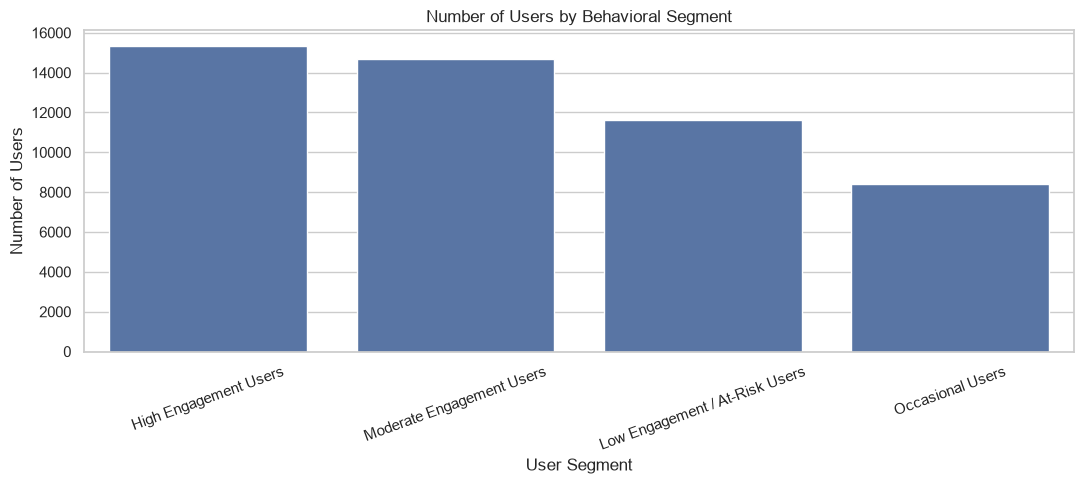

In [41]:
plt.figure(figsize=(11, 5))

plot_data = segment_sizes.sort_values("user_count", ascending=False)

sns.barplot(
    data=plot_data,
    x="segment",
    y="user_count"
)

plt.title("Number of Users by Behavioral Segment")
plt.xlabel("User Segment")
plt.ylabel("Number of Users")
plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(VIZ_DIR / "segment_sizes.png", dpi=150, bbox_inches="tight")
plt.show()


## 17. User-Level Identification

Every user receives:
- A K-Means cluster ID
- A business-friendly segment name

This makes the model useful for targeted marketing and retention activities.


In [42]:
user_assignments = df[
    ["user_id", "cluster", "segment"]
].copy()

print("Sample user-level assignments:")
display(user_assignments.head(20))


Sample user-level assignments:


,user_id,cluster,segment
0,100000,0,Low Engagement / At-Risk Users
1,100001,1,Moderate Engagement Users
2,100002,0,Low Engagement / At-Risk Users
3,100003,3,High Engagement Users
4,100004,3,High Engagement Users
5,100005,1,Moderate Engagement Users
6,100006,1,Moderate Engagement Users
7,100007,1,Moderate Engagement Users
8,100008,2,Occasional Users
9,100009,3,High Engagement Users


In [43]:
# Count users in each business segment
display(
    user_assignments["segment"]
    .value_counts()
    .rename_axis("segment")
    .reset_index(name="user_count")
)


,segment,user_count
0,High Engagement Users,15349
1,Moderate Engagement Users,14660
2,Low Engagement / At-Risk Users,11599
3,Occasional Users,8392


In [44]:
# Example: show users from each segment
for segment_name in [
    "High Engagement Users",
    "Moderate Engagement Users",
    "Low Engagement / At-Risk Users",
    "Occasional Users"
]:
    print(f"\n{segment_name}")
    display(
        user_assignments[
            user_assignments["segment"] == segment_name
        ].head(10)
    )



High Engagement Users


,user_id,cluster,segment
3,100003,3,High Engagement Users
4,100004,3,High Engagement Users
9,100009,3,High Engagement Users
11,100011,3,High Engagement Users
12,100012,3,High Engagement Users
16,100016,3,High Engagement Users
18,100018,3,High Engagement Users
24,100024,3,High Engagement Users
25,100025,3,High Engagement Users
27,100027,3,High Engagement Users



Moderate Engagement Users


,user_id,cluster,segment
1,100001,1,Moderate Engagement Users
5,100005,1,Moderate Engagement Users
6,100006,1,Moderate Engagement Users
7,100007,1,Moderate Engagement Users
14,100014,1,Moderate Engagement Users
19,100019,1,Moderate Engagement Users
22,100022,1,Moderate Engagement Users
23,100023,1,Moderate Engagement Users
26,100026,1,Moderate Engagement Users
30,100030,1,Moderate Engagement Users



Low Engagement / At-Risk Users


,user_id,cluster,segment
0,100000,0,Low Engagement / At-Risk Users
2,100002,0,Low Engagement / At-Risk Users
10,100010,0,Low Engagement / At-Risk Users
15,100015,0,Low Engagement / At-Risk Users
17,100017,0,Low Engagement / At-Risk Users
20,100020,0,Low Engagement / At-Risk Users
21,100021,0,Low Engagement / At-Risk Users
29,100029,0,Low Engagement / At-Risk Users
31,100031,0,Low Engagement / At-Risk Users
37,100037,0,Low Engagement / At-Risk Users



Occasional Users


,user_id,cluster,segment
8,100008,2,Occasional Users
13,100013,2,Occasional Users
28,100028,2,Occasional Users
41,100041,2,Occasional Users
48,100048,2,Occasional Users
52,100052,2,Occasional Users
55,100055,2,Occasional Users
58,100058,2,Occasional Users
62,100062,2,Occasional Users
75,100075,2,Occasional Users


## 18. Business Action Mapping

In [45]:
business_actions = pd.DataFrame({
    "segment": [
        "High Engagement Users",
        "Moderate Engagement Users",
        "Low Engagement / At-Risk Users",
        "Occasional Users"
    ],
    "business_focus": [
        "Retention and value expansion",
        "Engagement growth",
        "Churn prevention",
        "Re-engagement"
    ],
    "recommended_actions": [
        "Loyalty programs, premium offers, early access and advocacy programs",
        "Personalized recommendations, feature education and engagement campaigns",
        "Retention offers, reminders, re-engagement campaigns and onboarding support",
        "Targeted reminders, relevant content and campaigns designed to increase usage"
    ]
})

display(business_actions)


,segment,business_focus,recommended_actions
0,High Engagement Users,Retention and value expansion,"Loyalty programs, premium offers, early access..."
1,Moderate Engagement Users,Engagement growth,"Personalized recommendations, feature educatio..."
2,Low Engagement / At-Risk Users,Churn prevention,"Retention offers, reminders, re-engagement cam..."
3,Occasional Users,Re-engagement,"Targeted reminders, relevant content and campa..."


## 19. Save Project Outputs

The following files will be generated:
- Cluster profiles
- Segment profiles
- User-level cluster assignments
- Segment sizes
- Business action mapping
- Visualization images


In [46]:
cluster_profile.to_csv(
    OUTPUT_DIR / "cluster_profiles.csv"
)

segment_profile.to_csv(
    OUTPUT_DIR / "segment_profiles.csv"
)

user_assignments.to_csv(
    OUTPUT_DIR / "user_cluster_assignments.csv",
    index=False
)

segment_sizes.to_csv(
    OUTPUT_DIR / "segment_sizes.csv",
    index=False
)

business_actions.to_csv(
    OUTPUT_DIR / "business_action_mapping.csv",
    index=False
)

print("All analysis outputs saved successfully. ✅")


All analysis outputs saved successfully. ✅


## 20. Save Machine Learning Models

The trained preprocessing and ML components are saved so that the final Streamlit application can reuse the same transformations and K-Means model.


In [47]:
joblib.dump(
    scaler,
    MODEL_DIR / "scaler.pkl"
)

joblib.dump(
    pca,
    MODEL_DIR / "pca.pkl"
)

joblib.dump(
    kmeans,
    MODEL_DIR / "kmeans_model.pkl"
)

with open(MODEL_DIR / "feature_names.txt", "w", encoding="utf-8") as file:
    file.write("\n".join(behavior_features))

print("ML models saved successfully. ✅")


ML models saved successfully. ✅


## 21. Final Results Summary

In [48]:
print("=" * 60)
print("APP USER BEHAVIOR SEGMENTATION - FINAL SUMMARY")
print("=" * 60)

print(f"\nTotal users analyzed: {len(df):,}")
print(f"Behavioral features used: {len(behavior_features)}")
print(f"Final number of clusters: {OPTIMAL_K}")
print(f"Final silhouette score: {final_silhouette:.4f}")
print(f"PCA variance explained by PC1 + PC2: {total_variance:.2%}")

print("\nUser Segments:")
for cluster_id in sorted(segment_mapping):
    segment_name = segment_mapping[cluster_id]
    count = (df["segment"] == segment_name).sum()
    pct = count / len(df) * 100
    print(f"- {segment_name}: {count:,} users ({pct:.2f}%)")

print("\nBusiness Outcome:")
print("- High-value users can be targeted with loyalty/premium strategies.")
print("- Low-engagement users can be prioritized for retention campaigns.")
print("- Moderate users can receive personalized engagement strategies.")
print("- Occasional users can receive re-engagement campaigns.")


APP USER BEHAVIOR SEGMENTATION - FINAL SUMMARY

Total users analyzed: 50,000
Behavioral features used: 15
Final number of clusters: 4
Final silhouette score: 0.0528
PCA variance explained by PC1 + PC2: 13.68%

User Segments:
- Low Engagement / At-Risk Users: 11,599 users (23.20%)
- Moderate Engagement Users: 14,660 users (29.32%)
- Occasional Users: 8,392 users (16.78%)
- High Engagement Users: 15,349 users (30.70%)

Business Outcome:
- High-value users can be targeted with loyalty/premium strategies.
- Low-engagement users can be prioritized for retention campaigns.
- Moderate users can receive personalized engagement strategies.
- Occasional users can receive re-engagement campaigns.


## 22. Conclusion

The project demonstrates how **unsupervised machine learning** can transform raw app activity data into actionable user segments without requiring predefined labels.

### Key outcomes
- User behavior was analyzed using EDA.
- Relevant behavioral features were selected.
- Features were normalized using StandardScaler.
- K-Means clustering created four behavioral groups.
- Elbow Method and Silhouette Score were used for model evaluation.
- PCA provided a 2D visualization of the clusters.
- Cluster profiles enabled business-friendly segment interpretation.
- Every user was assigned to a segment for targeted actions.

### Business value
The resulting segmentation can support:
- Targeted marketing
- Churn-risk identification
- Retention planning
- Personalized user experiences
- Product feature optimization
- Data-driven business decisions
